In [2]:
import sys
import os
sys.path.append(os.path.abspath('../analysis'))

import numpy as np
import matplotlib.pyplot as plt
# from Plate import Plate
from Analysis import Analysis
from OptimizedPlate import OptimizedPlate
import pandas as pd

In [3]:
# Set matplotlib to use LaTeX for text rendering to match MATLAB script
# Note: This requires a LaTeX distribution to be installed on your system.
try:
    plt.rcParams.update({
        "text.usetex": True,
        "font.family": "serif",
        "text.latex.preamble": r"\usepackage{amsmath}",
    })
except Exception as e:
    print(f"Could not enable LaTeX rendering: {e}\nFalling back to default.")

In [4]:
D = 1.0       # Flexural rigidity [Nm^2]
P = -1.0      # Concentrated load [N]
a = 1.0       # Length side X [m]
b = 1.0       # Length side Y [m]
t = 0.002     # Thickness side Z [m]

xi = 0.2      # X position of load [m]
eta = 0.3     # Y position of load [m]

space_res_x = 0.0005  # [m]
space_res_y = 0.0005  # [m]

# Initial N is not critical as Analysis will find the converged value
# p = OptimizedPlate(a, b, t, space_res_x, space_res_y, xi, eta, D, P, 10)
ana = Analysis(r'C:\Users\rossi\Documents\tesi\apdl\sim\sim_0.006_0.024.parquet')

df = pd.read_parquet(r'C:\Users\rossi\Documents\tesi\apdl\sim\sim_0.006_0.024.parquet')

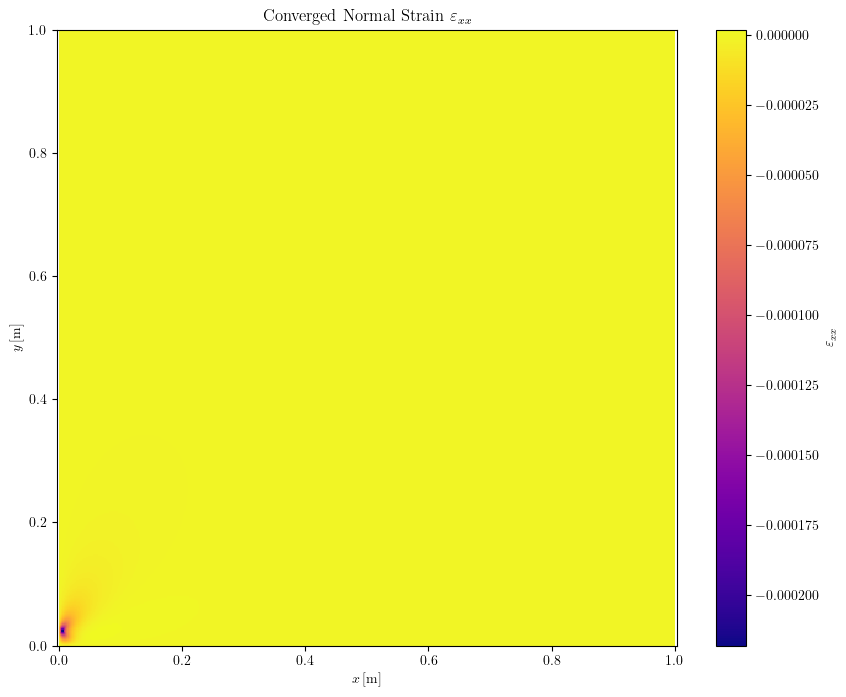

In [5]:
# %% Plot Strain exx
# Note: MATLAB script title was for epsilon_xy, but it plotted exx. Corrected here.
X_mesh, Y_mesh = np.meshgrid(df['X'].unique(), df['Y'].unique(), indexing='xy')
plt.figure(num='Strain exx', figsize=(10, 8))
# The analysis object stores strains as (Nx, Ny), pcolormesh needs (Ny, Nx)
plt.pcolormesh(X_mesh, Y_mesh, ana.exx.T, cmap='plasma', shading='auto', rasterized=True)
plt.axis('tight')
plt.axis('equal')
plt.title(f'Converged Normal Strain $\\varepsilon_{{xx}}$')
plt.xlabel('$x \\left[\\mathrm{m}\\right]$')
plt.ylabel('$y \\left[\\mathrm{m}\\right]$')
plt.colorbar(label='$\\varepsilon_{xx}$')
plt.show()

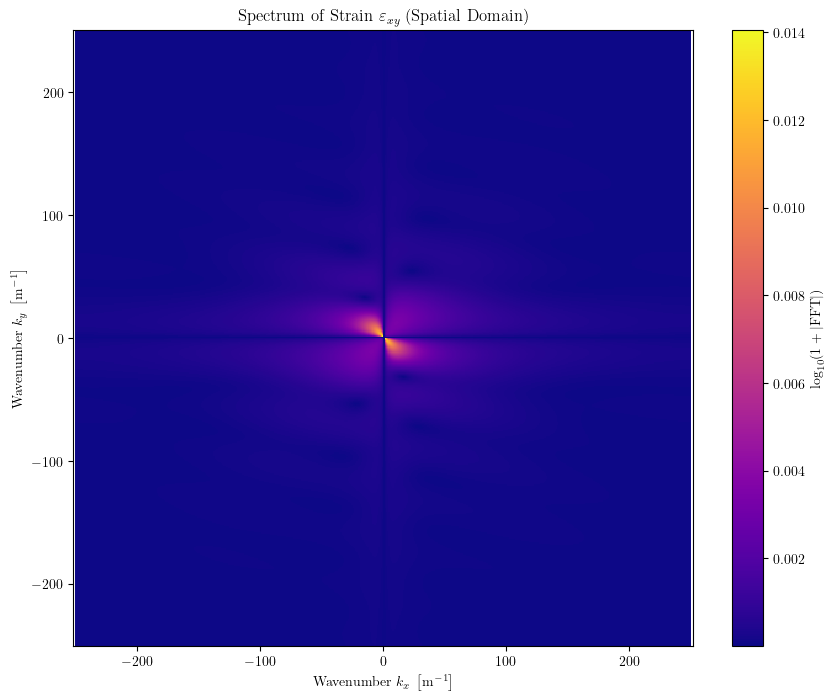

In [ ]:
# %% Plot Spectral Analysis of Strain exy
plt.figure(num='Spectral Analysis Strain exy', figsize=(10, 8))
# The FFT fields are (Ny, Nx)
plt.pcolormesh(ana.kx, ana.ky, np.log10(1 + np.abs(ana.ft_exy)), cmap='plasma', shading='auto', rasterized=True)
plt.axis('tight')
plt.axis('equal')
plt.colorbar(label='$\\log_{10}(1 + |\\mathrm{FFT}|)$')
plt.xlabel('Wavenumber $k_x \\; \\left[\\mathrm{m}^{-1}\\right]$')
plt.ylabel('Wavenumber $k_y \\; \\left[\\mathrm{m}^{-1}\\right]$')
plt.title('Spectrum of Strain $\\varepsilon_{xy}$ (Spatial Domain)')
plt.show()

RISULTATI ANALISI SPETTRALE e_xx
--------------------------------------------------------------------------------
Direzione X
Numero d'onda critico (99% energia): 78.66 1/m
Grandezza mesh massima: 6.36 mm
Direzione Y
Numero d'onda critico (99% energia): 35.57 1/m
Grandezza mesh massima: 14.06 mm
RISULTATI ANALISI SPETTRALE e_yy
--------------------------------------------------------------------------------
Direzione X
Numero d'onda critico (99% energia): 53.61 1/m
Grandezza mesh massima: 9.33 mm
Direzione Y
Numero d'onda critico (99% energia): 93.69 1/m
Grandezza mesh massima: 5.34 mm
RISULTATI ANALISI SPETTRALE e_xy
--------------------------------------------------------------------------------
Direzione X
Numero d'onda critico (99% energia): 127.76 1/m
Grandezza mesh massima: 3.91 mm
Direzione Y
Numero d'onda critico (99% energia): 79.66 1/m
Grandezza mesh massima: 6.28 mm


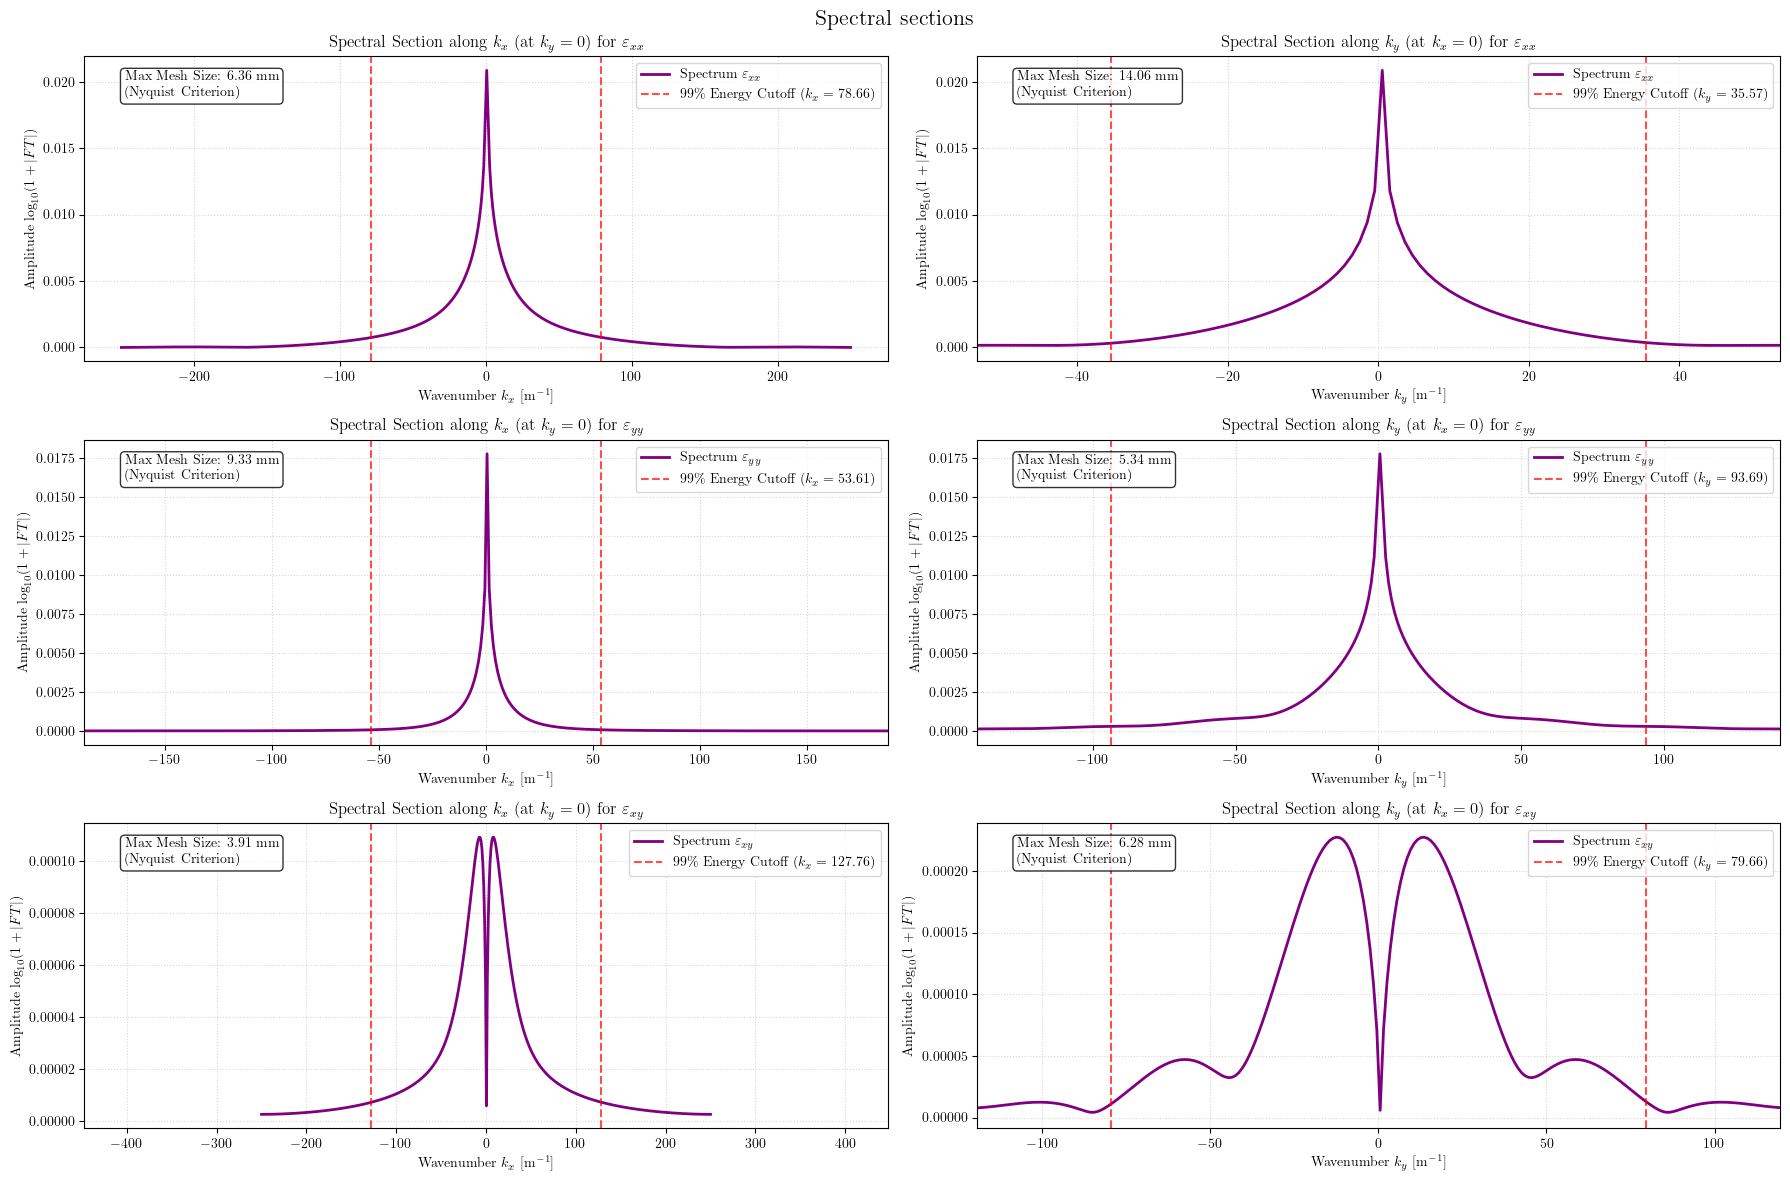

In [10]:
center_ky_idx = len(ana.ky) // 2
center_kx_idx = len(ana.kx) // 2

strains_data = [
    (ana.ft_exx, ana.find_sampling_freq_exx, r'\varepsilon_{xx}'),
    (ana.ft_eyy, ana.find_sampling_freq_eyy, r'\varepsilon_{yy}'),
    (ana.ft_exy, ana.find_sampling_freq_exy, r'\varepsilon_{xy}')
]

fig, axes = plt.subplots(3, 2, figsize=(18, 12))
fig.suptitle('Spectral sections', fontsize=16)

for i, (ft_field, freq_func, tex_label) in enumerate(strains_data):
    # Calculate cutoff using Analysis class functions
    fs_x, fs_y = freq_func()
    
    # Calculate max mesh size according to Nyquist criterion [mm]
    h_max_x = 1000 / (2 * fs_x) if fs_x != 0 else 0
    h_max_y = 1000 / (2 * fs_y) if fs_y != 0 else 0

    # --- Slice along kx at ky=0 ---
    ax_x = axes[i, 0]
    spectrum_slice = np.log10(1 + np.abs(ft_field[center_ky_idx, :]))
    ax_x.plot(ana.kx, spectrum_slice, linewidth=2, label=f'Spectrum ${tex_label}$', color='purple')
    
    ax_x.axvline(x=fs_x, color='r', linestyle='--', alpha=0.7, label=f'99\\% Energy Cutoff ($k_x={fs_x:.2f}$)')
    ax_x.axvline(x=-fs_x, color='r', linestyle='--', alpha=0.7)
    ax_x.text(0.05, 0.95, f'Max Mesh Size: {h_max_x:.2f} mm\n(Nyquist Criterion)', transform=ax_x.transAxes, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    ax_x.grid(True, which='both', linestyle=':', alpha=0.5)
    ax_x.set_xlabel(r'Wavenumber $k_x \ [\mathrm{m}^{-1}]$')
    ax_x.set_ylabel(r'Amplitude $\log_{10}(1+|FT|)$')
    ax_x.set_title(f'Spectral Section along $k_x$ (at $k_y=0$) for ${tex_label}$')
    ax_x.legend()
    ax_x.set_xlim([-fs_x * 3.5, fs_x * 3.5])

    # --- Slice along ky at kx=0 ---
    ax_y = axes[i, 1]
    spectrum_slice_y = np.log10(1 + np.abs(ft_field[:, center_kx_idx]))
    ax_y.plot(ana.ky, spectrum_slice_y, linewidth=2, label=f'Spectrum ${tex_label}$', color='purple')
    
    ax_y.axvline(x=fs_y, color='r', linestyle='--', alpha=0.7, label=f'99\\% Energy Cutoff ($k_y={fs_y:.2f}$)')
    ax_y.axvline(x=-fs_y, color='r', linestyle='--', alpha=0.7)
    ax_y.text(0.05, 0.95, f'Max Mesh Size: {h_max_y:.2f} mm\n(Nyquist Criterion)', transform=ax_y.transAxes, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    ax_y.grid(True, which='both', linestyle=':', alpha=0.5)
    ax_y.set_xlabel(r'Wavenumber $k_y \ [\mathrm{m}^{-1}]$')
    ax_y.set_ylabel(r'Amplitude $\log_{10}(1+|FT|)$')
    ax_y.set_title(f'Spectral Section along $k_y$ (at $k_x=0$) for ${tex_label}$')
    ax_y.legend()
    ax_y.set_xlim([-fs_y * 1.5, fs_y * 1.5])

plt.tight_layout()
plt.show()

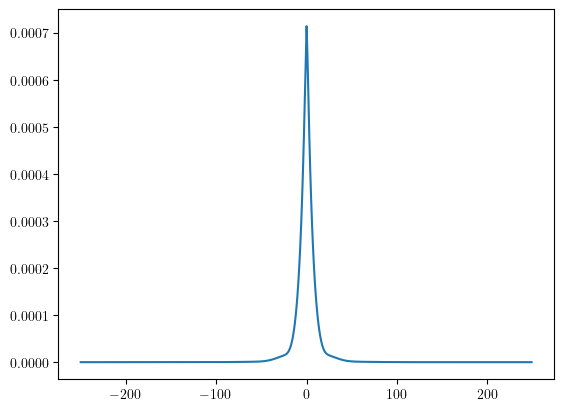

In [8]:
strain = df.query('X == 0.035')['EXX'].values
x = df['X'].unique()
x_p = np.fft.fftshift(np.fft.fftfreq(strain.size, d=(x[1] - x[0])))
plt.plot(x_p, np.abs(np.fft.fftshift(np.fft.fft(strain))))